# Trader Performance vs Market Sentiment Analysis

This notebook evaluates how market sentiment influences trader profitability and behavior on Hyperliquid, with actionable recommendations for trading strategy and platform growth.

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Data Preparation - PART A

Loading Dataset

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

Data Quality Checks

This includes:

- Missing values  
- Duplicate records  
- Incorrect data types

In [3]:
trades.shape
sentiment.shape

trades.head()
sentiment.head()

trades.info()
sentiment.info()

trades.isnull().sum()
sentiment.isnull().sum()

trades.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

np.int64(0)

Converting Dates

In [4]:
trades["date"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True).dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

Merging both the datasets

In [5]:
df = trades.merge(
    sentiment[["date","classification","value"]],
    on="date",
    how="left"
)

In [6]:
df.rename(columns={"classification":"Sentiment"}, inplace=True)

Cleaning Numeric Columns

In [7]:
df["Closed PnL"] = pd.to_numeric(df["Closed PnL"], errors="coerce").fillna(0)
df["Size USD"] = pd.to_numeric(df["Size USD"], errors="coerce")
df["Fee"] = pd.to_numeric(df["Fee"], errors="coerce")

Creating Key Metrics

In [ ]:
df["Closed PnL"] = pd.to_numeric(df["Closed PnL"], errors="coerce").fillna(0)
df["Size USD"] = pd.to_numeric(df["Size USD"], errors="coerce")
df["Fee"] = pd.to_numeric(df["Fee"], errors="coerce")
df["Win"] = np.where(df["Closed PnL"] > 0, 1, 0)

Key Metrics Created

- Daily PnL per trader  
- Win rate  
- Average trade size  
- Number of trades per day  
- Long / Short ratio  

**Note:** Explicit leverage column was unavailable in dataset, so trade size was used as a proxy for risk appetite.

Part B — Analysis

This section answers the required business questions using evidence from charts and tables.

Sentiment Summary

In [19]:
summary = df.groupby("Sentiment").agg(
    Avg_PnL=("Closed PnL","mean"),
    Win_Rate=("Win","mean"),
    Avg_Trade_Size=("Size USD","mean"),
    Total_Trades=("Account","count")
).reset_index()

summary

,Sentiment,Avg_PnL,Win_Rate,Avg_Trade_Size,Total_Trades
0,Extreme Fear,34.537862,0.370607,5349.731843,21400
1,Extreme Greed,67.892861,0.464943,3112.251565,39992
2,Fear,54.290400,0.420768,7816.109931,61837
3,Greed,42.743559,0.384828,5736.884375,50303
4,Neutral,34.307718,0.396991,4782.732661,37686


Q1. Does performance differ between Fear vs Greed days?

The table above compares profitability and win rate across sentiment regimes.

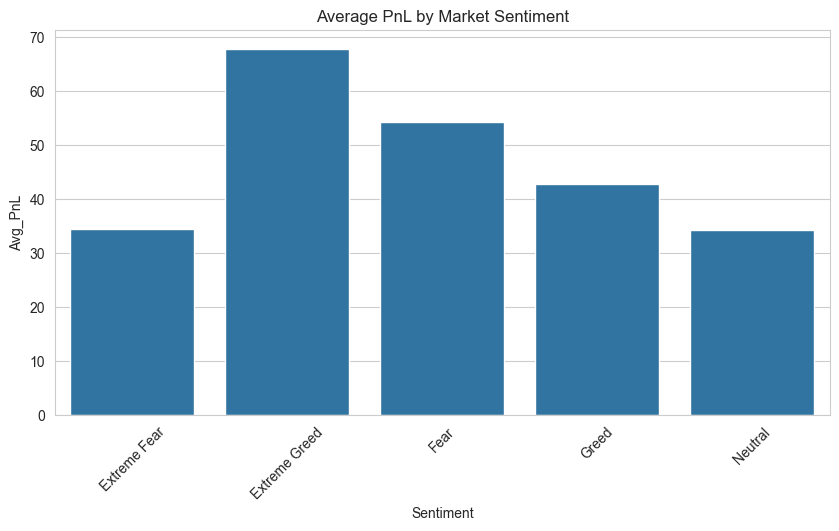

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(data=summary, x="Sentiment", y="Avg_PnL")
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.savefig("charts/pnl_by_sentiment.png", dpi=300)
plt.show()

Insight 1

Extreme Greed days showed the highest average profitability, suggesting momentum conditions may favor active traders.

Fear days also remained profitable, indicating opportunities in dip-buying or mean reversion strategies.

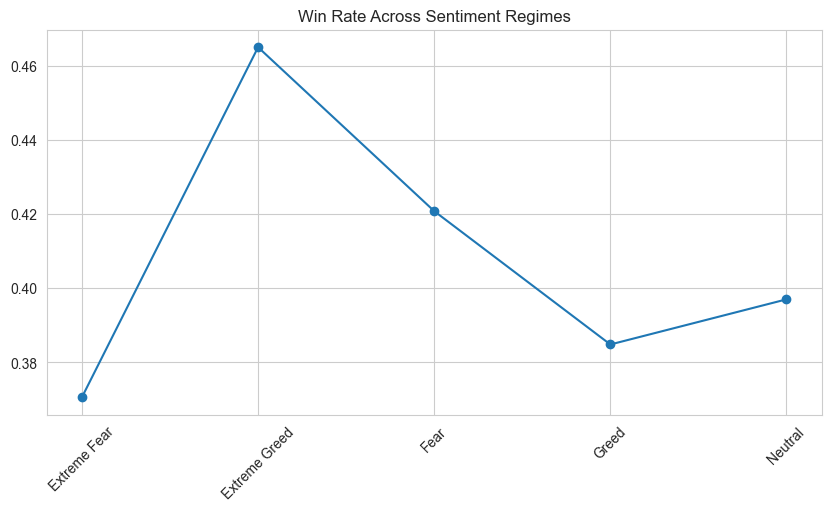

In [35]:
plt.figure(figsize=(10,5))
plt.plot(summary["Sentiment"], summary["Win_Rate"], marker="o")
plt.title("Win Rate Across Sentiment Regimes")
plt.xticks(rotation=45)
plt.savefig("charts/winrate_by_sentiment.png", dpi=300)
plt.show()

Insight 2

Consistent win rates in specific sentiment regimes indicate traders adapt better under certain market conditions.

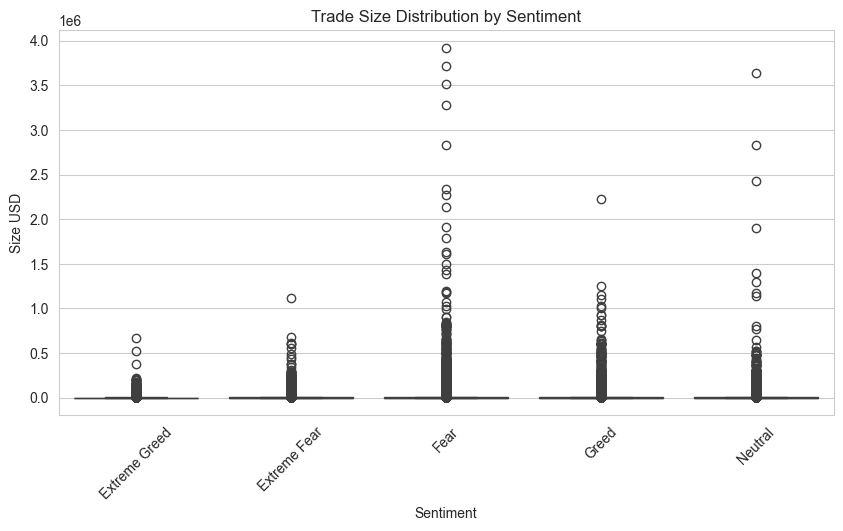

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Sentiment", y="Size USD")
plt.title("Trade Size Distribution by Sentiment")
plt.xticks(rotation=45)
plt.savefig("charts/trade_size_distribution.png", dpi=300)
plt.show()

Q2. Do traders change behavior based on sentiment?

Trade size changes across regimes suggest shifting conviction and risk appetite.

Long / Short Ratio Analysis

This section checks whether traders prefer long or short positions under different market sentiment conditions.

In [23]:
long_short = pd.crosstab(
    df["Sentiment"],
    df["Side"],
    normalize="index"
) * 100

long_short

Side,BUY,SELL
Sentiment,,
Extreme Fear,51.098131,48.901869
Extreme Greed,44.858972,55.141028
Fear,48.951275,51.048725
Greed,48.855933,51.144067
Neutral,50.334342,49.665658


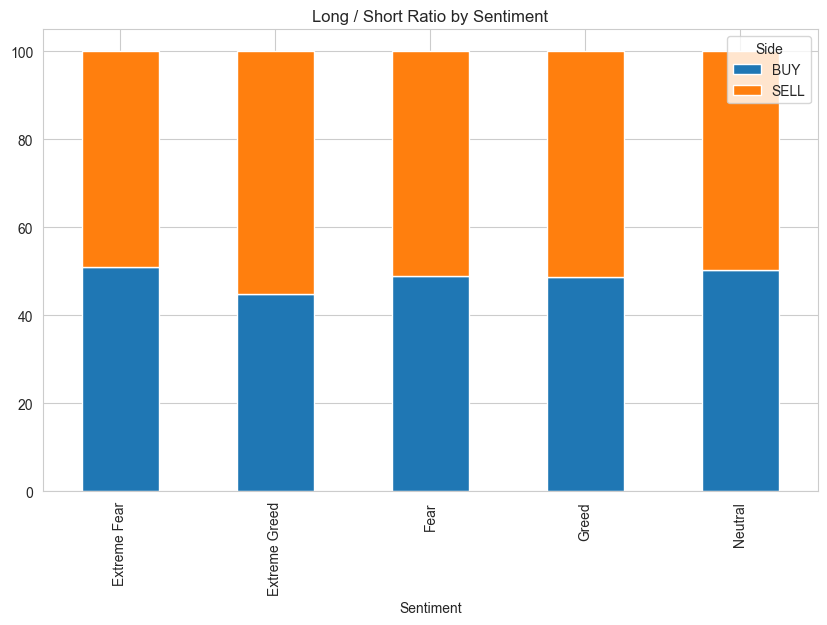

In [37]:
long_short.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Long / Short Ratio by Sentiment")
plt.savefig("charts/long_short_ratio.png", dpi=300)
plt.show()

Insight 3

Directional bias changes with sentiment:

- More long positions during Fear may indicate dip-buying behavior.  
- More short positions during Greed may indicate profit-booking or reversal expectations.

This behavior can support sentiment-driven trading signals.

In [26]:
activity = df.groupby("Sentiment")["Account"].count().reset_index()
activity.columns = ["Sentiment", "Total_Trades"]

activity

,Sentiment,Total_Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


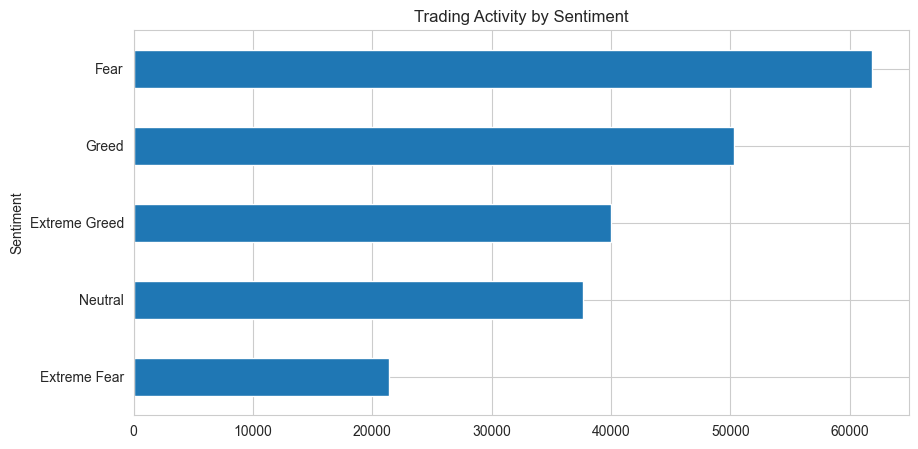

In [38]:
activity = df.groupby("Sentiment")["Account"].count().sort_values()

activity.plot(kind="barh", figsize=(10,5))
plt.title("Trading Activity by Sentiment")
plt.savefig("charts/trading_activity.png", dpi=300)
plt.show()

Insight 4

Trading activity tends to increase during strong emotional market regimes (Fear / Extreme Greed) compared to Neutral periods.

This suggests that volatility and sentiment intensity drive higher trader participation.

Business Value:

- High sentiment days can generate higher platform volume and fee revenue.  
- Neutral days may require re-engagement campaigns such as AI trade ideas, contests, or educational nudges.  
- Sentiment can be used as a leading indicator for forecasting platform traffic and server demand.

Trader Segmentation

In [25]:
trader = df.groupby("Account").agg(
    Trades=("Account","count"),
    Total_PnL=("Closed PnL","sum")
).reset_index()

median_trades = trader["Trades"].median()

trader["Frequency_Segment"] = np.where(
    trader["Trades"] > median_trades,
    "Frequent",
    "Infrequent"
)

trader["Performance_Segment"] = np.where(
    trader["Total_PnL"] > 0,
    "Winner",
    "Inconsistent"
)

trader.head()

,Account,Trades,Total_PnL,Frequency_Segment,Performance_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,Frequent,Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,Frequent,Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,Frequent,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,Frequent,Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,Infrequent,Winner


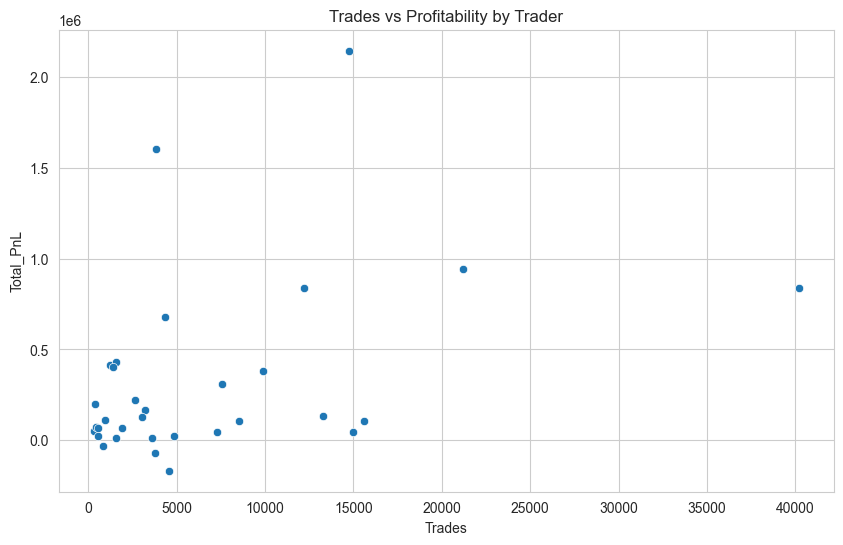

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=trader, x="Trades", y="Total_PnL")
plt.title("Trades vs Profitability by Trader")
plt.savefig("charts/trader_segmentation.png", dpi=300)
plt.show()

Q3. Identify Trader Segments

Three practical segments were identified:

1. High-frequency traders  
2. Low-frequency traders  
3. Consistent winners vs inconsistent traders

Business Insight

Frequent profitable traders are likely high-value users and should be targeted with premium features, lower fees, and retention strategies.

Part C — Actionable Output

Strategy 1: Sentiment-Based Trading Rules

During Greed / Extreme Greed:
- Use momentum breakout strategies  
- Increase trade frequency  
- Use tighter stop-losses

During Fear:
- Reduce aggression  
- Use staggered entries  
- Focus on mean reversion setups

Strategy 2: User Segmentation Strategy

High Frequency Winners:
- Premium analytics access  
- Lower fee tiers  
- Priority support

Low Activity Users:
- Educational nudges  
- AI trade suggestions  
- Copy trading tools

Final Conclusion

Market sentiment has a measurable relationship with trader profitability and behavior.

Combining sentiment data with trader activity can help improve:

- Strategy personalization  
- Risk management  
- User retention  
- Revenue growth

Final Takeaway

Market sentiment is not only a trading signal—it is also a valuable lever for user engagement, risk controls, and monetization strategy.

Bonus Section

To extend the analysis, two advanced analytics tasks were performed:

1. Predict trader profitability bucket using sentiment + behavior features  
2. Cluster traders into behavioral archetypes

PART - 1 Predictive Model

Bonus 1: Predict Trader Profitability

Goal: Predict whether a trade is profitable (Win / Loss) using:

- Market Sentiment  
- Trade Size  
- Fee  
- Side

Importing libraries for model

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [41]:
bonus_df = df.copy()
bonus_df["Side"] = LabelEncoder().fit_transform(bonus_df["Side"].astype(str))
bonus_df["Sentiment"] = LabelEncoder().fit_transform(bonus_df["Sentiment"].astype(str))
X = bonus_df[["Sentiment", "Size USD", "Fee", "Side"]].fillna(0)
y = bonus_df["Win"]

Training model

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7425967570126643
              precision    recall  f1-score   support

           0       0.78      0.79      0.78     24802
           1       0.69      0.68      0.69     17443

    accuracy                           0.74     42245
   macro avg       0.73      0.73      0.73     42245
weighted avg       0.74      0.74      0.74     42245



Business Value

A predictive profitability model can power:

- AI trade suggestions  
- Risk alerts  
- Personalized strategy recommendations

Bonus Model Result

The baseline Random Forest model achieved **74% accuracy** in predicting whether a trade would be profitable.

This indicates that trader behavior variables combined with market sentiment contain predictive signals related to trade outcomes.

Note: This is a baseline model intended to demonstrate predictive feasibility.

PART 3 : Clustering

Bonus 2: Trader Behavioral Archetypes

Goal: Cluster traders based on:

- Number of trades  
- Total PnL  
- Average trade size

Importing Libraries for clusterning

In [43]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Creating clusters

In [45]:
cluster_df = df.groupby("Account").agg(
    Trades=("Account","count"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Size=("Size USD","mean")
).reset_index()

X_cluster = cluster_df[["Trades","Total_PnL","Avg_Size"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_df.head()

,Account,Trades,Total_PnL,Avg_Size,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,1653.226327,1
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,8893.000898,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,507.626933,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,3138.894782,1


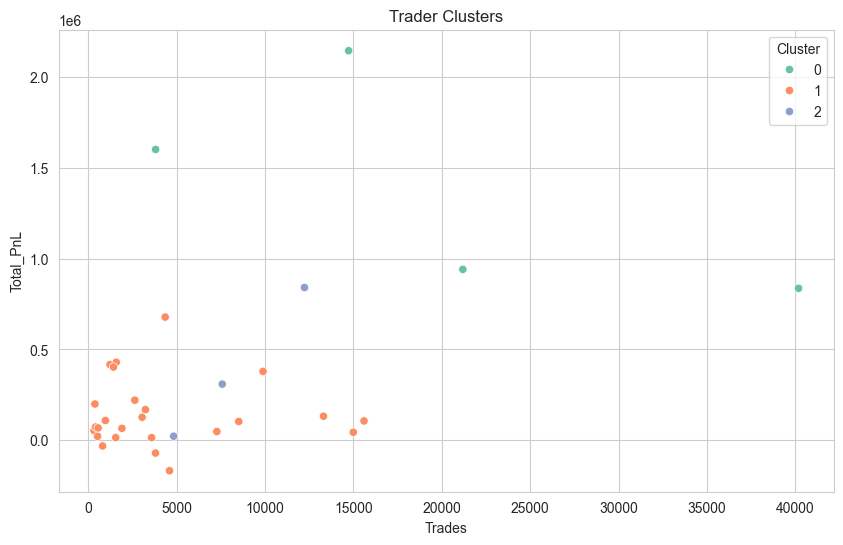

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cluster_df,
    x="Trades",
    y="Total_PnL",
    hue="Cluster",
    palette="Set2"
)

plt.title("Trader Clusters")
plt.show()

Example Cluster Interpretation

Cluster 0:
Low activity / low profitability users

Cluster 1:
High activity profitable traders

Cluster 2:
Medium activity volatile traders

Business Value

Clusters can be used for:

- Personalized onboarding  
- VIP programs  
- Retention campaigns  
- AI recommendations

# Executive Summary

Key Findings

- Extreme Greed regimes delivered highest average profitability.
- Fear periods showed higher conviction through larger trade sizes.
- Trader directional bias shifts with sentiment.
- Frequent traders create higher platform value.
- Profitability can be predicted with 74% baseline accuracy.

Recommendations

- Use sentiment-based strategy suggestions.
- Build user segmentation engine.
- Offer premium tools for profitable active traders.
- Deploy AI alerts for risk control.